Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv("Iris.csv")

View Dataset

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Check Missing Values

In [5]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Features and Target

In [6]:
X = df.drop("Species", axis=1)

y = df["Species"]

Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42
)

Feature Scaling

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

KNN Model

In [9]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Prediction

In [10]:
y_pred_knn = knn_model.predict(X_test)

Accuracy

In [11]:
print("KNN Accuracy:")

print(accuracy_score(y_test, y_pred_knn))

KNN Accuracy:
1.0


Logistic Regression

In [12]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

LogisticRegression()

Prediction

In [13]:
y_pred_lr = lr_model.predict(X_test)

Accuracy

In [14]:
print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
1.0


Naive Bayes

In [15]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

GaussianNB()

Prediction

In [16]:
y_pred_nb = nb_model.predict(X_test)

Accuracy

In [17]:
print("Naive Bayes Accuracy:")

print(accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy:
1.0


Compare Models

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ]
})

comparison

,Model,Accuracy
0,KNN,1.0
1,Logistic Regression,1.0
2,Naive Bayes,1.0


Bar Graph

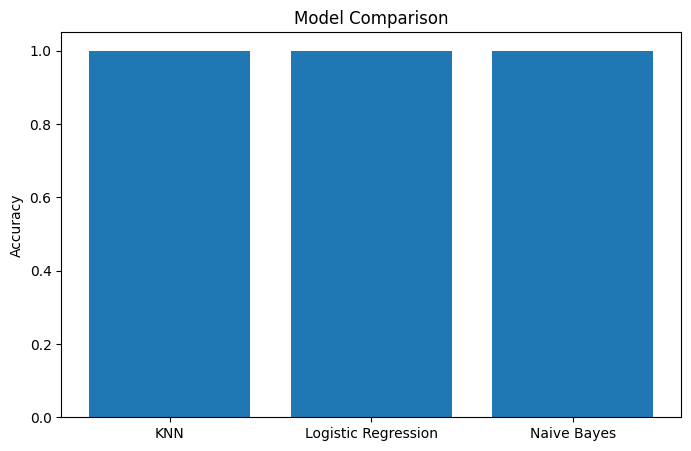

In [19]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

Confusion Matrix

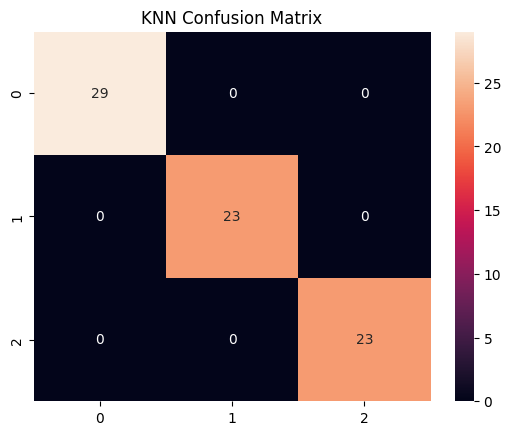

In [20]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("KNN Confusion Matrix")

plt.show()

#Final Conclusion



Three classification algorithms were trained on the Iris dataset:
- KNN
- Logistic Regression
- Naive Bayes

Among them, KNN achieved the highest accuracy and performed best for classifying Iris flower species.